In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Preparing the dataset
df = pd.read_csv('./data.csv')
col = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[col]


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

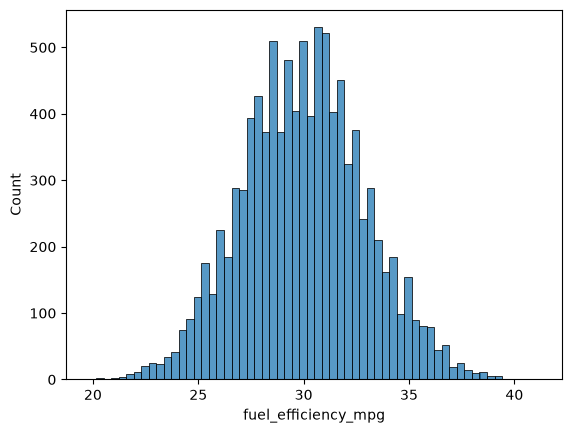

In [ ]:
# EDA

sns.histplot(df.fuel_efficiency_mpg) # No long tail

In [ ]:
# Q1: horsepower
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [ ]:
# Q2: 254
df.horsepower.median()

np.float64(254.0)

In [9]:
# Prepare and split the dataset
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [11]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

def train_linear_regression(X, y, r=0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [12]:
# reset index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Create y vector of results
y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

# Delete feature from dataset
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [ ]:
df_train_hp_0 = df_train.copy()
df_train_hp_mean = df_train.copy()

df_train_hp_0.horsepower = df_train_hp_0.horsepower.fillna(0)
df_train_hp_mean.horsepower = df_train_hp_mean.horsepower.fillna(df_train_hp_mean.horsepower.mean())

w0_0, w_0 = train_linear_regression(df_train_hp_0, y_train)
w0_mean, w_mean = train_linear_regression(df_train_hp_mean, y_train)

y_0_val_pred = w0_0 + df_val.dot(w_0)
rmse_0 = rmse(y_val, y_0_val_pred)

y_mean_val_pred = w0_mean + df_val.dot(w_mean)
rmse_mean = rmse(y_val, y_mean_val_pred)

# Q3: Better with 0
round(rmse_0, 3), round(rmse_mean, 3) 

(np.float64(2.19), np.float64(2.186))

In [ ]:
# Q4: 0
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression(df_train_hp_0, y_train, r)
    y_pred = w0 + df_val.dot(w)
    e = rmse(y_val, y_pred)
    print(f"r: {r} --- {round(e, 4)}")

r: 0 --- 2.1896
r: 0.01 --- 2.1903
r: 0.1 --- 2.2102
r: 1 --- 2.3413
r: 5 --- 2.4038
r: 10 --- 2.4143
r: 100 --- 2.4244


In [ ]:
# Q5: 0.029

scores = []
for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    # reset index
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    # Create y vector of results
    y_train = df_train['fuel_efficiency_mpg']
    y_val = df_val['fuel_efficiency_mpg']
    y_test = df_test['fuel_efficiency_mpg']

    # Delete feature from dataset
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    df_train.horsepower = df_train.horsepower.fillna(0)
    df_val.horsepower = df_val.horsepower.fillna(0)

    w0, w = train_linear_regression(df_train, y_train)
    y_pred = w0 + df_val.dot(w)
    e = rmse(y_val, y_pred)

    print(f"r: {r} --- {round(e, 4)}")
    scores.append(round(e, 4))

round(np.std(scores), 3)

r: 100 --- 2.2392
r: 100 --- 2.2021
r: 100 --- 2.1634
r: 100 --- 2.2044
r: 100 --- 2.2019
r: 100 --- 2.2458
r: 100 --- 2.2697
r: 100 --- 2.1908
r: 100 --- 2.2166
r: 100 --- 2.207


np.float64(0.029)

In [ ]:
# Q6: 2.236

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

# reset index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Create y vector of results
y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

# Delete feature from dataset
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

df_train.horsepower = df_train.horsepower.fillna(0)
df_val.horsepower = df_val.horsepower.fillna(0)
df_test.horsepower = df_test.horsepower.fillna(0)

df_full_train = pd.concat([df_train, df_val])
y_full_train = pd.concat([y_train, y_val])

w0, w = train_linear_regression(df_full_train, y_full_train, r=0.001)
y_pred = w0 + df_test.dot(w)
e = rmse(y_test, y_pred)

print(f"r: {0.001} --- {round(e, 3)}")

r: 0.001 --- 2.236
